# 09 — Git History Training Data

Mines real fix / refactor commits from ARO application repos and the ARO examples
directory to build training pairs grounded in actual before/after code changes.

Git logs are read **every time this notebook runs** — no upfront caching.

## Two pair types per commit hunk

| Type | User prompt | Assistant answer |
|------|-------------|------------------|
| **explanation** | Why was this ARO code changed? + old code | commit-message explanation |
| **fix** | Fix this ARO code (given explanation) + old code | new (fixed) code |

## Output

| File | Source repos |
|------|--------------|
| `git_applications_pairs.jsonl` | `/Users/kris/Projects/ARO-Application/*` |
| `git_examples_pairs.jsonl` | ARO repo `Examples/` + `Book/` + `Proposals/` fix commits |

A final cell appends both files to `knowledge_pairs.jsonl`.

## Setup

In [1]:
import sys, importlib, json, re, subprocess
from pathlib import Path
from collections import defaultdict

_cfg_dir = Path('.').resolve()
if str(_cfg_dir) not in sys.path:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *

ARO_APPLICATION_ROOT = Path('/Users/kris/Projects/ARO-Application')

# Commit message keywords that signal a fix / improvement worth training on
FIX_PATTERN = re.compile(
    r'\b(fix|refactor|correct|simplif|improv|replac|rewrite|clean|migrat|updat|use typed|eliminate|remove duplication)\b',
    re.IGNORECASE,
)

# Minimum removed/added non-blank ARO lines to form a useful hunk
MIN_HUNK_LINES = 1

SYSTEM = (
    "You are an expert ARO (Action Result Object) programmer. "
    "ARO is a DSL where every statement is: Verb the <Result> preposition [the] <Object>. "
    "Feature sets follow (Name: Business Activity) { statements }. "
    "Variables are immutable. String concatenation uses ++. "
    "Event publishing uses Emit a <Name: event> with <data>."
)

print('Setup complete.')
print(f'  ARO-Application root : {ARO_APPLICATION_ROOT}')
print(f'  ARO repo root        : {ARO_ROOT}')

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Setup complete.
  ARO-Application root : /Users/kris/Projects/ARO-Application
  ARO repo root        : /Users/kris/Projects/ARO-App


## Shared helpers

In [2]:
def git(*args, cwd):
    """Run a git command and return stdout, or '' on error."""
    result = subprocess.run(
        ['git'] + list(args),
        cwd=str(cwd), capture_output=True, text=True,
    )
    return result.stdout if result.returncode == 0 else ''


def get_fix_commits(repo_path: Path, file_glob: str = '*.aro') -> list[dict]:
    """
    Return a list of commit dicts for commits that touch `file_glob` and whose
    message matches FIX_PATTERN.

    Each dict: {sha, subject, body, diff_text}
    """
    # One-liner log: sha TAB subject
    log = git(
        'log', '--format=%H\t%s\t%b<END_BODY>',
        '--diff-filter=M',      # only modified files (not pure adds/deletes)
        '--', file_glob,
        cwd=repo_path,
    )
    if not log.strip():
        return []

    commits = []
    for block in log.split('<END_BODY>'):
        block = block.strip()
        if not block:
            continue
        first_line, *rest = block.splitlines()
        parts = first_line.split('\t', 2)
        if len(parts) < 2:
            continue
        sha, subject = parts[0], parts[1]
        body = '\n'.join(rest).strip()

        if not FIX_PATTERN.search(subject + ' ' + body):
            continue

        diff_text = git(
            'show', sha,
            '--no-color', '--unified=3',
            '--', file_glob,
            cwd=repo_path,
        )
        if diff_text:
            commits.append({
                'sha': sha[:10],
                'subject': subject,
                'body': body,
                'diff_text': diff_text,
                'repo': repo_path.name,
            })

    return commits


def parse_diff_hunks(diff_text: str) -> list[dict]:
    """
    Parse a unified diff and return a list of hunks, each containing:
      {file, old_lines: [str], new_lines: [str]}
    Skips hunks that are pure whitespace / context-only changes.
    """
    hunks = []
    current_file = None
    old_lines, new_lines = [], []

    def _flush():
        nonlocal old_lines, new_lines
        o = [l for l in old_lines if l.strip()]
        n = [l for l in new_lines if l.strip()]
        if len(o) >= MIN_HUNK_LINES and len(n) >= MIN_HUNK_LINES:
            hunks.append({'file': current_file, 'old_lines': o, 'new_lines': n})
        old_lines, new_lines = [], []

    in_diff = False
    for line in diff_text.splitlines():
        if line.startswith('diff --git'):
            _flush()
            in_diff = True
            m = re.search(r'b/(.+)$', line)
            current_file = m.group(1) if m else None
            continue
        if not in_diff:
            continue
        if line.startswith('@@'):
            _flush()
            continue
        if line.startswith('---') or line.startswith('+++'):
            continue
        if line.startswith('-') and not line.startswith('---'):
            old_lines.append(line[1:])
        elif line.startswith('+') and not line.startswith('+++'):
            new_lines.append(line[1:])

    _flush()
    return hunks


def build_explanation(subject: str, body: str) -> str:
    """Compose a clean explanation string from commit subject + body."""
    parts = [subject.strip()]
    if body:
        # Trim noise lines (Git trailer lines, blank separators)
        body_lines = [
            l for l in body.splitlines()
            if l.strip() and not re.match(r'^(Co-authored|Signed-off|Reviewed)', l, re.I)
        ]
        if body_lines:
            parts.append('\n'.join(body_lines))
    return '\n\n'.join(parts)


def hunks_to_pairs(commit: dict) -> list[dict]:
    """
    Convert one commit into a list of training pair dicts.
    Returns [] if no usable hunks found.
    """
    explanation = build_explanation(commit['subject'], commit['body'])
    hunks = parse_diff_hunks(commit['diff_text'])
    pairs = []

    for hunk in hunks:
        old_code = '\n'.join(hunk['old_lines'])
        new_code = '\n'.join(hunk['new_lines'])
        fname    = hunk['file'] or 'main.aro'
        source   = f"{commit['repo']}/{fname}@{commit['sha']}"

        # --- pair type 1: old code → explanation why it was changed ---
        pairs.append({
            'messages': [
                {'role': 'system',    'content': SYSTEM},
                {'role': 'user',      'content':
                    f'Why was this ARO code changed?\n\n'
                    f'```aro\n{old_code}\n```'},
                {'role': 'assistant', 'content': explanation},
            ],
            'task_type': 'debugging',
            'source': source,
        })

        # --- pair type 2: explanation + old code → new code ---
        pairs.append({
            'messages': [
                {'role': 'system',    'content': SYSTEM},
                {'role': 'user',      'content':
                    f'{explanation}\n\n'
                    f'Fix this ARO code accordingly:\n\n'
                    f'```aro\n{old_code}\n```'},
                {'role': 'assistant', 'content':
                    f'```aro\n{new_code}\n```'},
            ],
            'task_type': 'debugging',
            'source': source,
        })

    return pairs


print('Helpers loaded.')

Helpers loaded.


## Cell 1 — ARO-Application repos

Reads git history from every application in `/Users/kris/Projects/ARO-Application`.

In [3]:
app_pairs = []
app_stats = {}

app_repos = sorted(
    [d for d in ARO_APPLICATION_ROOT.iterdir() if d.is_dir() and (d / '.git').exists()]
)

print(f'Found {len(app_repos)} git repos under {ARO_APPLICATION_ROOT}\n')

for repo in app_repos:
    commits = get_fix_commits(repo)
    pairs   = []
    for c in commits:
        pairs.extend(hunks_to_pairs(c))

    app_stats[repo.name] = {'commits': len(commits), 'pairs': len(pairs)}
    app_pairs.extend(pairs)
    print(f'  {repo.name:<25}  {len(commits):>3} qualifying commits  →  {len(pairs):>4} pairs')

print(f'\nTotal: {len(app_pairs)} training pairs')

# Write to JSONL
OUT_APPS = SCRIPT_DIR / 'git_applications_pairs.jsonl'
with OUT_APPS.open('w') as f:
    for p in app_pairs:
        f.write(json.dumps(p) + '\n')

print(f'Saved → {OUT_APPS}')

Found 7 git repos under /Users/kris/Projects/ARO-Application

  Crawler                      1 qualifying commits  →     6 pairs
  FediTerm                     0 qualifying commits  →     0 pairs
  StatusPost                   0 qualifying commits  →     0 pairs
  Sumup                        3 qualifying commits  →    18 pairs
  SystemLoadMonitor            0 qualifying commits  →     0 pairs
  rulpz                        1 qualifying commits  →    20 pairs
  sf                           3 qualifying commits  →     8 pairs

Total: 52 training pairs
Saved → /Users/kris/Projects/ARO-App/Train/script/git_applications_pairs.jsonl


## Cell 2 — ARO repo examples & runtime

Reads fix commits from the ARO repository itself — both `Examples/` `.aro` files
and `Sources/` Swift files that contain inline ARO snippets in comments or strings.

In [4]:
aro_pairs = []
aro_stats = {}

# Sub-paths inside ARO_ROOT to mine; each entry is (label, glob)
ARO_TARGETS = [
    ('Examples',  'Examples/**/*.aro'),
    ('Book',      'Book/**/*.md'),
    ('Proposals', 'Proposals/*.md'),
]

print(f'Mining ARO repo: {ARO_ROOT}\n')

for label, glob in ARO_TARGETS:
    commits = get_fix_commits(ARO_ROOT, glob)
    # Override repo name so source tags are descriptive
    for c in commits:
        c['repo'] = f'aro/{label}'
    pairs = []
    for c in commits:
        pairs.extend(hunks_to_pairs(c))

    aro_stats[label] = {'commits': len(commits), 'pairs': len(pairs)}
    aro_pairs.extend(pairs)
    print(f'  {label:<12}  {len(commits):>3} qualifying commits  →  {len(pairs):>4} pairs')

print(f'\nTotal: {len(aro_pairs)} training pairs')

# Write to JSONL
OUT_ARO = SCRIPT_DIR / 'git_examples_pairs.jsonl'
with OUT_ARO.open('w') as f:
    for p in aro_pairs:
        f.write(json.dumps(p) + '\n')

print(f'Saved → {OUT_ARO}')

Mining ARO repo: /Users/kris/Projects/ARO-App

  Examples       57 qualifying commits  →   442 pairs
  Book           37 qualifying commits  →  1612 pairs
  Proposals      25 qualifying commits  →   262 pairs

Total: 2316 training pairs
Saved → /Users/kris/Projects/ARO-App/Train/script/git_examples_pairs.jsonl


## Inspect samples

In [5]:
import random

all_pairs = app_pairs + aro_pairs
sample = random.sample(all_pairs, min(3, len(all_pairs)))

for i, p in enumerate(sample):
    print(f'── Sample {i+1}  [{p["source"]}] ──────────────────────────────────')
    for msg in p['messages']:
        if msg['role'] == 'system':
            continue
        role = msg['role'].upper()
        print(f'[{role}]\n{msg["content"][:400]}')
        if len(msg['content']) > 400:
            print('...')
        print()

── Sample 1  [aro/Book/Book/AROByExample/Chapter05-FetchingPages.md@1feabaf0c2] ──────────────────────────────────
[USER]
Update books and runtime for atomic Store dedup and crawler improvements

- Add `contains` operator to compiled mode (RuntimeBridge.swift)
- Add atomic `new-entry` binding to repository Store (RepositoryStorage.swift)
- Execute Application-End handlers in Runtime.run() for batch apps (FeatureSetExecutor.swift)
- Register aro_action_split in compiled mode (ActionBridge.swift)
- Fix LLVM external de
...

[ASSISTANT]
```aro
   Handles the CrawlPage event to fetch URLs and trigger
   link extraction.
Eleven lines. Extract, log, fetch, parse, emit, return. Every line does exactly one thing, and the handler reads like a description of what it does.
## 5.9 What ARO Does Well Here
**Simple HTTP.** `<Request> the <html> from the <url>.` -- One line for HTTP GET. No client setup, no promise handling, no error callbac
...

── Sample 2  [aro/Examples/Examples/ContextAware/main.

## Append to knowledge_pairs.jsonl

Appends both JSONL files to the pipeline's knowledge pairs so the next fine-tune run
includes this data.  Run this cell only when you want to incorporate the pairs.

In [6]:
PAIRS_FILE.parent.mkdir(parents=True, exist_ok=True)

total_appended = 0
with PAIRS_FILE.open('a') as out:
    for path in (OUT_APPS, OUT_ARO):
        lines = [l for l in path.read_text().splitlines() if l.strip()]
        for line in lines:
            out.write(line + '\n')
        total_appended += len(lines)
        print(f'  {path.name:<35} {len(lines)} pairs appended')

print(f'\nTotal appended to {PAIRS_FILE}: {total_appended}')

  git_applications_pairs.jsonl        52 pairs appended
  git_examples_pairs.jsonl            2316 pairs appended

Total appended to /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl: 2368


## Summary

In [7]:
print('═' * 60)
print('Git History Training Data — Summary')
print('═' * 60)

print('\nARO-Application repos:')
for name, s in sorted(app_stats.items()):
    print(f'  {name:<25}  {s["commits"]:>3} commits  {s["pairs"]:>4} pairs')

print('\nARO repo:')
for name, s in sorted(aro_stats.items()):
    print(f'  {name:<25}  {s["commits"]:>3} commits  {s["pairs"]:>4} pairs')

print(f'\nTotal pairs : {len(app_pairs) + len(aro_pairs)}')
print(f'  {OUT_APPS.name}: {len(app_pairs)}')
print(f'  {OUT_ARO.name}: {len(aro_pairs)}')

════════════════════════════════════════════════════════════
Git History Training Data — Summary
════════════════════════════════════════════════════════════

ARO-Application repos:
  Crawler                      1 commits     6 pairs
  FediTerm                     0 commits     0 pairs
  StatusPost                   0 commits     0 pairs
  Sumup                        3 commits    18 pairs
  SystemLoadMonitor            0 commits     0 pairs
  rulpz                        1 commits    20 pairs
  sf                           3 commits     8 pairs

ARO repo:
  Book                        37 commits  1612 pairs
  Examples                    57 commits   442 pairs
  Proposals                   25 commits   262 pairs

Total pairs : 2368
  git_applications_pairs.jsonl: 52
  git_examples_pairs.jsonl: 2316


In [8]:
# ── Samples per category ─────────────────────────────────────────────────────
import json, random

_app_pairs, _aro_pairs = [], []
for path, target in ((OUT_APPS, _app_pairs), (OUT_ARO, _aro_pairs)):
    if path.exists():
        with open(path) as f:
            for line in f:
                if line.strip():
                    target.append(json.loads(line))

def _show_git_samples(pairs, label, n=2):
    if not pairs:
        print(f'  (no pairs in {label})')
        return
    # Split into explanation vs fix by looking at user message content
    explanation = [p for p in pairs if 'Why was this' in p['messages'][1]['content']]
    fix         = [p for p in pairs if p not in explanation]
    for sub_label, pool in [('explanation', explanation), ('fix', fix)]:
        if not pool:
            continue
        print(f'\n{"─"*72}')
        print(f'  {label} → {sub_label}  ({len(pool)} pairs)')
        print('─'*72)
        for s in random.sample(pool, min(n, len(pool))):
            user_msg = s['messages'][1]['content']
            asst_msg = s['messages'][2]['content']
            print(f'[{s["source"]}]')
            print(f'Q: {user_msg[:240]}{"..." if len(user_msg) > 240 else ""}')
            print(f'A: {asst_msg[:280]}{"..." if len(asst_msg) > 280 else ""}')
            print()

_show_git_samples(_app_pairs, 'ARO-Application repos')
_show_git_samples(_aro_pairs, 'ARO repo (Examples/Book/Proposals)')


────────────────────────────────────────────────────────────────────────
  ARO-Application repos → explanation  (26 pairs)
────────────────────────────────────────────────────────────────────────
[rulpz/posts.aro@a10512db54]
Q: Why was this ARO code changed?

```aro
   POST   /posts          → create post (auth required)
   DELETE /posts/{id}     → delete own post (auth required)
   Session validation is done by querying the sessions table.
   The runtime returns ...
A: Fix ARO plugin loading: correct .so path, verbs key, qualifier signature

Fix it and test it with `docker compose up`.
[During debugging]
instead of `Create the <page-name> with "index.html". Transform the <html>
from the <template: page-name>.` you can write:
`Transform the <htm...

[rulpz/auth.aro@a10512db54]
Q: Why was this ARO code changed?

```aro
   POST /login  → find-or-create user, issue session token
   DELETE /session → delete session
   Login is username-only (no password). A new user is created
   automati

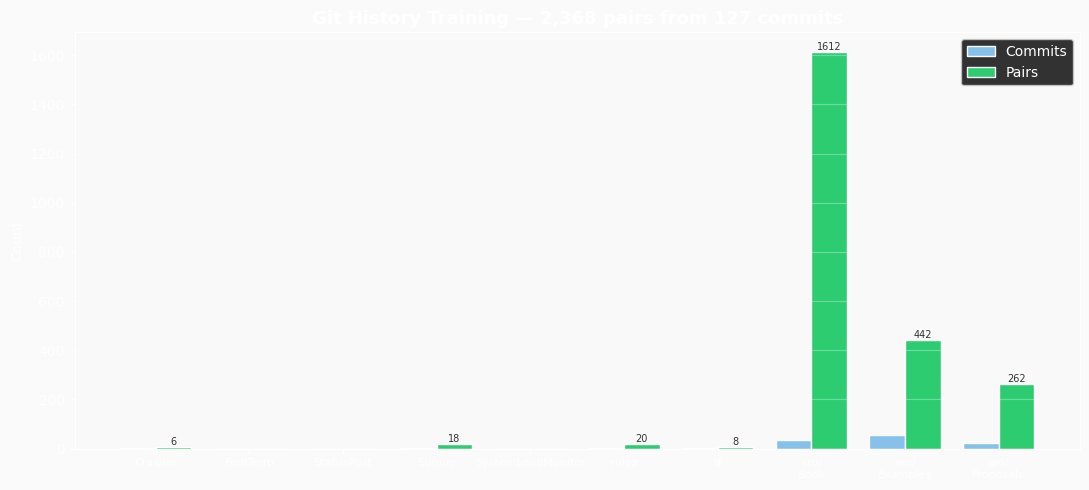

Saved: run/2026-03-23/09_git_training.png


In [9]:
# ── Final status: git training pairs per source ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '09_git_training.png'

# Merge app_stats and aro_stats into one list for plotting
_sources = []
_commits = []
_pairs   = []

for name, s in sorted(app_stats.items()):
    _sources.append(name.replace('-', '\n'))
    _commits.append(s['commits'])
    _pairs.append(s['pairs'])

for name, s in sorted(aro_stats.items()):
    _sources.append(f'aro/\n{name}')
    _commits.append(s['commits'])
    _pairs.append(s['pairs'])

x = np.arange(len(_sources))
w = 0.38

fig, ax = plt.subplots(figsize=(max(10, len(_sources) * 1.1), 5))
b1 = ax.bar(x - w/2, _commits, w, label='Commits', color='#85c1e9', edgecolor='white')
b2 = ax.bar(x + w/2, _pairs,   w, label='Pairs',   color='#2ecc71', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(_sources, fontsize=8)
ax.set_ylabel('Count')
ax.set_title(
    f'Git History Training — {sum(_pairs):,} pairs from {sum(_commits)} commits',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in b2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontsize=7, color='#333')
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')
